## L-VQE vs. VQE - MaxCut

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from l_vqe_engine import (
    build_maxcut_hamiltonian,
    best_known_maxcut_cost,
    simulate_one_lvqe,
    simulate_one_vqe,
)

CONFIG = {
    "n_seeds": 10,
    "optimizer": "SMO",
    "shots": 2000,
    "evals_per_layer": 600,
    "vqe_budget": 3000,
    "device": "lightning.qubit",
}

RAW_CSV = Path("csv_files/lvqe_vs_vqe_maxcut_raw.csv")

In [8]:
def generate_mobius_ladder(n_nodes):
    assert n_nodes % 2 == 0, "Möbius ladder requires an even number of nodes"
    G = nx.cycle_graph(n_nodes)
    half = n_nodes // 2
    for i in range(half):
        G.add_edge(i, i + half)
    return G

def build_graph_suite():
    return [
        ("mobius_10", generate_mobius_ladder(10)),
        ("3reg_8",    nx.random_regular_graph(d=3, n=8,  seed=42)),
        ("3reg_10",   nx.random_regular_graph(d=3, n=10, seed=42)),
        ("3reg_12",   nx.random_regular_graph(d=3, n=12, seed=42)),
        ("3reg_14",   nx.random_regular_graph(d=3, n=14, seed=42)),
    ]

for name, G in build_graph_suite():
    print(f"{name:10s} nodes={G.number_of_nodes()}  qubits={G.number_of_nodes()}")

mobius_10  nodes=10  qubits=10
3reg_8     nodes=8  qubits=8
3reg_10    nodes=10  qubits=10
3reg_12    nodes=12  qubits=12
3reg_14    nodes=14  qubits=14


In [ ]:
def run_lvqe_vs_vqe_maxcut(graph_name, G, cfg):
    records = []
    n_q = G.number_of_nodes()

    print(f"\n{'='*60}\nGraph: {graph_name} | nodes={n_q} | qubits={n_q}")
    c_bkv = best_known_maxcut_cost(G)
    print(f"  C_bkv = {c_bkv:.4f}")
    H = build_maxcut_hamiltonian(G)

    for seed in range(cfg["n_seeds"]):
        print(f"\n  Seed {seed+1}/{cfg['n_seeds']}")

        for max_l in [0, 1, 2]:
            res = simulate_one_lvqe(
                n_q=n_q, H=H, max_layers=max_l, shots=cfg["shots"],
                max_iter_per_layer=cfg["evals_per_layer"],
                rng=np.random.default_rng(seed),
                device_name=cfg["device"], optimizer=cfg["optimizer"],
            )
            records.append({"graph": graph_name, "seed": seed,
                            "algorithm": "L-VQE", "n_layers": max_l,
                            "rho": res["final_cost"] / c_bkv})
            print(f"    done L-VQE  max_layers={max_l}")

        for n_l in [1, 2]:
            res = simulate_one_vqe(
                n_q=n_q, H=H, n_layers=n_l, shots=cfg["shots"],
                max_evals=cfg["vqe_budget"],
                rng=np.random.default_rng(seed),
                device_name=cfg["device"], optimizer=cfg["optimizer"],
            )
            records.append({"graph": graph_name, "seed": seed,
                            "algorithm": "VQE", "n_layers": n_l,
                            "rho": res["final_cost"] / c_bkv})
            print(f"    done VQE    n_layers={n_l}")

    return pd.DataFrame(records)

In [10]:
all_results = []
for graph_name, G in build_graph_suite():
    all_results.append(run_lvqe_vs_vqe_maxcut(graph_name, G, CONFIG))
    pd.concat(all_results, ignore_index=True).to_csv(RAW_CSV, index=False)

full_df = pd.concat(all_results, ignore_index=True)
print(f"\nSaved {len(full_df)} rows to {RAW_CSV}")


Graph: mobius_10 | nodes=10 | qubits=10
  C_bkv = -15.0000

  Seed 1/10
  Layer 0  (10 params) ... 

/Users/ayseidilevci/layered_vqe/venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


cost = -15.000000
    done L-VQE  max_layers=0
  Layer 0  (10 params) ... cost = -15.000000
  Layer 1  (46 params) ... cost = -14.997000
    done L-VQE  max_layers=1
  Layer 0  (10 params) ... cost = -14.997000
  Layer 1  (46 params) ... cost = -14.996000
  Layer 2  (82 params) ... cost = -14.995000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/10
  Layer 0  (10 params) ... cost = -14.994000
    done L-VQE  max_layers=0
  Layer 0  (10 params) ... cost = -10.999500
  Layer 1  (46 params) ... cost = -14.995000
    done L-VQE  max_layers=1
  Layer 0  (10 params) ... cost = -11.000000
  Layer 1  (46 params) ... cost = -14.998000
  Layer 2  (82 params) ... cost = -14.991000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/10
  Layer 0  (10 params) ... cost = -10.998000
    done L-VQE  max_layers=0
  Layer 0  (10 params) ... cost = -10.999500
  Layer 1  (46 params) ... cost = -14.991000
    done L-VQE 

/Users/ayseidilevci/layered_vqe/venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


cost = -10.000000
    done L-VQE  max_layers=0
  Layer 0  (8 params) ... cost = -9.999500
  Layer 1  (36 params) ... cost = -10.000000
    done L-VQE  max_layers=1
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -9.997500
  Layer 2  (64 params) ... cost = -9.996000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/10
  Layer 0  (8 params) ... cost = -10.000000
    done L-VQE  max_layers=0
  Layer 0  (8 params) ... cost = -9.992000
  Layer 1  (36 params) ... cost = -9.997000
    done L-VQE  max_layers=1
  Layer 0  (8 params) ... cost = -10.000000
  Layer 1  (36 params) ... cost = -9.998000
  Layer 2  (64 params) ... cost = -9.997000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/10
  Layer 0  (8 params) ... cost = -10.000000
    done L-VQE  max_layers=0
  Layer 0  (8 params) ... cost = -9.998500
  Layer 1  (36 params) ... cost = -9.996000
    done L-VQE  max_layers=1
  

...

cost = -11.999500
    done L-VQE  max_layers=0
  Layer 0  (10 params) ... cost = -12.000000
  Layer 1  (46 params) ... cost = -11.995000
    done L-VQE  max_layers=1
  Layer 0  (10 params) ... cost = -12.000000
  Layer 1  (46 params) ... cost = -11.999500
  Layer 2  (82 params) ... cost = -12.000000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/10
  Layer 0  (10 params) ... cost = -12.000000
    done L-VQE  max_layers=0
  Layer 0  (10 params) ... cost = -11.998000
  Layer 1  (46 params) ... cost = -12.000000
    done L-VQE  max_layers=1
  Layer 0  (10 params) ... cost = -11.998500
  Layer 1  (46 params) ... cost = -12.000000
  Layer 2  (82 params) ... cost = -11.998000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/10
  Layer 0  (10 params) ... cost = -13.000000
    done L-VQE  max_layers=0
  Layer 0  (10 params) ... cost = -12.998000
  Layer 1  (46 params) ... cost = -12.998500
    done L-VQE 

/Users/ayseidilevci/layered_vqe/venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


cost = -14.000000
    done L-VQE  max_layers=0
  Layer 0  (12 params) ... cost = -14.000000
  Layer 1  (56 params) ... cost = -14.997500
    done L-VQE  max_layers=1
  Layer 0  (12 params) ... cost = -13.999500
  Layer 1  (56 params) ... cost = -14.999500
  Layer 2  (100 params) ... cost = -14.999000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/10
  Layer 0  (12 params) ... cost = -15.997000
    done L-VQE  max_layers=0
  Layer 0  (12 params) ... cost = -15.997000
  Layer 1  (56 params) ... cost = -15.986000
    done L-VQE  max_layers=1
  Layer 0  (12 params) ... cost = -16.000000
  Layer 1  (56 params) ... cost = -15.994500
  Layer 2  (100 params) ... cost = -15.991000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/10
  Layer 0  (12 params) ... cost = -15.998500
    done L-VQE  max_layers=0
  Layer 0  (12 params) ... cost = -16.000000
  Layer 1  (56 params) ... cost = -15.994500
    done L-VQ

/Users/ayseidilevci/layered_vqe/venv/lib/python3.12/site-packages/pennylane/devices/device_api.py:207: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


cost = -15.995000
    done L-VQE  max_layers=0
  Layer 0  (14 params) ... cost = -15.998500
  Layer 1  (66 params) ... cost = -15.998000
    done L-VQE  max_layers=1
  Layer 0  (14 params) ... cost = -16.998500
  Layer 1  (66 params) ... cost = -16.995500
  Layer 2  (118 params) ... cost = -16.998000
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 2/10
  Layer 0  (14 params) ... cost = -15.999000
    done L-VQE  max_layers=0
  Layer 0  (14 params) ... cost = -15.996000
  Layer 1  (66 params) ... cost = -16.000000
    done L-VQE  max_layers=1
  Layer 0  (14 params) ... cost = -15.998000
  Layer 1  (66 params) ... cost = -15.999500
  Layer 2  (118 params) ... cost = -15.994500
    done L-VQE  max_layers=2
    done VQE    n_layers=1
    done VQE    n_layers=2

  Seed 3/10
  Layer 0  (14 params) ... cost = -16.999500
    done L-VQE  max_layers=0
  Layer 0  (14 params) ... cost = -16.999000
  Layer 1  (66 params) ... cost = -16.996500
    done L-VQ

In [ ]:
def pivot(df, agg):
    g = df.groupby(["graph", "algorithm", "n_layers"])["rho"].agg(agg).reset_index()
    vqe = g[g["algorithm"] == "VQE"].pivot(index="graph", columns="n_layers", values="rho")
    vqe.columns = [f"VQE_{c}L" for c in vqe.columns]
    lvqe = g[g["algorithm"] == "L-VQE"].pivot(index="graph", columns="n_layers", values="rho")
    lvqe.columns = [f"LVQE_{c}L" for c in lvqe.columns]
    return pd.concat([vqe, lvqe], axis=1).round(2)

best_table = pivot(full_df, "max")
avg_table  = pivot(full_df, "mean")
std_table  = pivot(full_df, "std")

print("Best approximation ratio:")
display(best_table)
print("\nAverage ± std:")
display(avg_table.astype(str) + " ± " + std_table.astype(str))

best_table.to_csv("csv_files/lvqe_vs_vqe_maxcut_best.csv")
avg_table.to_csv("csv_files/lvqe_vs_vqe_maxcut_avg.csv")

Best approximation ratio:


,VQE_1L,VQE_2L,LVQE_0L,LVQE_1L,LVQE_2L
graph,,,,,
3reg_10,1.0,1.0,1.0,1.0,1.0
3reg_12,1.0,1.0,1.0,1.0,1.0
3reg_14,1.0,1.0,1.0,1.0,1.0
3reg_8,1.0,1.0,1.0,1.0,1.0
mobius_10,1.0,1.0,1.0,1.0,1.0



Average ± std:


,VQE_1L,VQE_2L,LVQE_0L,LVQE_1L,LVQE_2L
graph,,,,,
3reg_10,0.95 ± 0.05,0.97 ± 0.04,0.97 ± 0.05,0.98 ± 0.03,0.98 ± 0.03
3reg_12,0.97 ± 0.05,0.96 ± 0.05,0.95 ± 0.09,0.96 ± 0.08,0.96 ± 0.08
3reg_14,1.0 ± 0.0,0.99 ± 0.02,0.97 ± 0.03,0.97 ± 0.03,0.98 ± 0.03
3reg_8,1.0 ± 0.0,1.0 ± 0.0,0.98 ± 0.06,1.0 ± 0.0,1.0 ± 0.0
mobius_10,0.97 ± 0.08,1.0 ± 0.0,0.97 ± 0.08,1.0 ± 0.0,1.0 ± 0.0


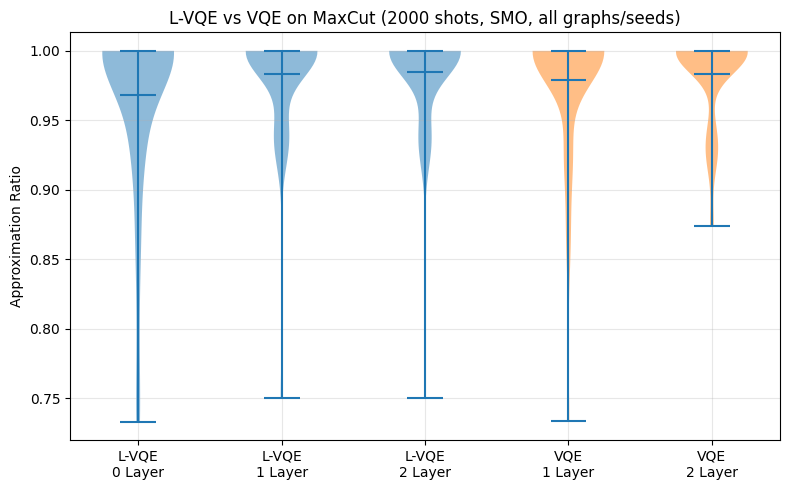

In [12]:
groups = [("L-VQE", 0), ("L-VQE", 1), ("L-VQE", 2), ("VQE", 1), ("VQE", 2)]
data, labels, colors = [], [], []
for algo, nl in groups:
    vals = full_df[(full_df["algorithm"] == algo) & (full_df["n_layers"] == nl)]["rho"].values
    data.append(vals)
    labels.append(f"{algo}\n{nl} Layer")
    colors.append("tab:blue" if algo == "L-VQE" else "tab:orange")

fig, ax = plt.subplots(figsize=(8, 5))
parts = ax.violinplot(data, showmeans=True, showextrema=True)
for body, c in zip(parts["bodies"], colors):
    body.set_facecolor(c)
    body.set_alpha(0.5)

shots_label = "full precision" if CONFIG["shots"] is None else f"{CONFIG['shots']} shots"
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("Approximation Ratio")
ax.set_title(f"L-VQE vs VQE on MaxCut ({shots_label}, {CONFIG['optimizer']}, all graphs/seeds)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()